In [ ]:
!pip install openai sentence-transformers scikit-learn pandas matplotlib seaborn datasets

In [2]:
import json
import re
from typing import List, Dict, Tuple, Optional
from collections import defaultdict, Counter

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import classification_report, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Используется устройство: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
def load_conll2003_data(max_train_examples: int = 1000, max_test_examples: int = 200):
    dataset = load_dataset("eriktks/conll2003", revision="convert/parquet")

    label_list = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG",
                  "B-LOC", "I-LOC", "B-MISC", "I-MISC"]

    def extract_entities(tokens, ner_tags):
        entities = []
        i = 0
        while i < len(tokens):
            if ner_tags[i] != 0:
                tag = ner_tags[i]
                entity_type = label_list[tag].split("-")[-1]
                start = i
                while i < len(tokens) and ner_tags[i] != 0:
                    i += 1
                entity_name = " ".join(tokens[start:i])
                entities.append({"name": entity_name, "type": entity_type})
            else:
                i += 1
        return entities

    train_data = []
    for example in dataset["train"]:
        entities = extract_entities(example["tokens"], example["ner_tags"])
        train_data.append({
            "text": " ".join(example["tokens"]),
            "entities": entities,
            "tokens": example["tokens"]
        })
        if len(train_data) >= max_train_examples:
            break

    test_data = []
    for example in dataset["test"]:
        entities = extract_entities(example["tokens"], example["ner_tags"])
        test_data.append({
            "text": " ".join(example["tokens"]),
            "entities": entities,
            "tokens": example["tokens"]
        })
        if len(test_data) >= max_test_examples:
            break

    return train_data, test_data, label_list

train_data, test_data, label_list = load_conll2003_data(max_train_examples=500, max_test_examples=100)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


conll2003/train/0000.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/283k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [4]:
class DEER_NER:
    def __init__(self, model_name: str = "Qwen/Qwen2.5-7B-Instruct", device: str = "cuda"):
        self.device = device
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=True
        )
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.token_stats = None
        self.entity_types = ["PER", "ORG", "LOC", "MISC"]

    def compute_token_statistics(self, train_data: List[Dict]):
        token_type_counts = defaultdict(lambda: defaultdict(int))
        total_tokens = defaultdict(int)

        for example in train_data:
            tokens = example["tokens"]
            labels = ["O"] * len(tokens)
            for entity in example["entities"]:
                entity_tokens = entity["name"].split()
                for i in range(len(tokens) - len(entity_tokens) + 1):
                    if tokens[i:i+len(entity_tokens)] == entity_tokens:
                        labels[i] = f"B-{entity['type']}"
                        for j in range(1, len(entity_tokens)):
                            labels[i+j] = f"I-{entity['type']}"
                        break
            for i, (token, label) in enumerate(zip(tokens, labels)):
                token_lower = token.lower()
                if label != "O":
                    token_type_counts[token_lower]["entity"] += 1
                else:
                    is_context = False
                    for j in range(max(0, i-2), min(len(tokens), i+3)):
                        if j != i and labels[j] != "O":
                            is_context = True
                            break
                    if is_context:
                        token_type_counts[token_lower]["context"] += 1
                    else:
                        token_type_counts[token_lower]["other"] += 1
                total_tokens[token_lower] += 1

        self.token_stats = {}
        for token, counts in token_type_counts.items():
            total = sum(counts.values())
            self.token_stats[token] = {
                "entity_prob": counts["entity"] / total if total > 0 else 0,
                "context_prob": counts["context"] / total if total > 0 else 0,
                "other_prob": counts["other"] / total if total > 0 else 0,
                "weight": np.log(total + 1)
            }

    def compute_similarity(self, train_text: str, test_text: str, lambda1: float = 0.5, lambda2: float = 0.5) -> float:
        train_tokens = set(train_text.lower().split())
        test_tokens = test_text.lower().split()

        token_score = 0
        for token in test_tokens:
            if token in train_tokens and token in self.token_stats:
                weight = self.token_stats[token]["entity_prob"] + 0.5 * self.token_stats[token]["context_prob"]
                token_score += weight * self.token_stats[token]["weight"]

        max_possible = sum(self.token_stats.get(t, {}).get("weight", 1) for t in test_tokens)
        token_score = token_score / max_possible if max_possible > 0 else 0
        semantic_score = len(train_tokens.intersection(test_tokens)) / len(train_tokens.union(test_tokens))

        return lambda1 * token_score + lambda2 * semantic_score

    def retrieve_demonstrations(self, test_text: str, train_data: List[Dict], k: int = 5) -> List[Dict]:
        similarities = []
        for idx, example in enumerate(train_data):
            sim = self.compute_similarity(example["text"], test_text)
            similarities.append((idx, sim))

        similarities.sort(key=lambda x: x[1], reverse=True)
        top_indices = [idx for idx, _ in similarities[:k]]

        return [train_data[idx] for idx in top_indices]

    def build_prompt(self, demonstrations: List[Dict], query_text: str, include_reflection: bool = False) -> str:

        system_prompt = """Ты - система извлечения именованных сущностей (NER).
Извлеки все сущности из текста и верни в формате JSON.
Поддерживаемые типы: PER (люди), ORG (организации), LOC (локации), MISC (разное)."""

        prompt = f"{system_prompt}\n\nПримеры:\n"

        for demo in demonstrations:
            entities_str = json.dumps({"named_entities": demo["entities"]}, ensure_ascii=False)
            prompt += f"Текст: {demo['text']}\nСущности: {entities_str}\n\n"

        prompt += f"Текст: {query_text}\nСущности: "

        if include_reflection:
            prompt += " (Пожалуйста, проверь еще раз границы сущностей)\n"

        return prompt

    def extract_entities_from_response(self, response: str) -> List[Dict]:
        try:
            json_match = re.search(r'\{.*\}', response, re.DOTALL)
            if json_match:
                data = json.loads(json_match.group())
                if "named_entities" in data:
                    return data["named_entities"]
        except:
            pass

        entities = []
        pattern = r'"name":\s*"([^"]+)"[^}]*"type":\s*"([^"]+)"'
        matches = re.findall(pattern, response)
        for name, etype in matches:
            if etype in self.entity_types:
                entities.append({"name": name, "type": etype})

        return entities

    def predict(self, text: str, demonstrations: List[Dict]) -> List[Dict]:
        prompt = self.build_prompt(demonstrations, text, include_reflection=False)

        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(self.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=512,
                temperature=0.1,
                do_sample=False,
                pad_token_id=self.tokenizer.eos_token_id
            )

        response = self.tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        entities = self.extract_entities_from_response(response)

        return entities

    def evaluate(self, test_data: List[Dict], train_data: List[Dict], k: int = 3) -> Dict:
        results = []

        for example in tqdm(test_data, desc="Оценка"):
            demonstrations = self.retrieve_demonstrations(example["text"], train_data, k=k)
            pred_entities = self.predict(example["text"], demonstrations)

            results.append({
                "text": example["text"],
                "true_entities": example["entities"],
                "pred_entities": pred_entities
            })
        return self.compute_metrics(results)

    def compute_metrics(self, results: List[Dict]) -> Dict:
        true_spans = set()
        pred_spans = set()

        for res in results:
            text = res["text"]
            for ent in res["true_entities"]:
                span = (ent["name"], ent["type"])
                true_spans.add(span)
            for ent in res["pred_entities"]:
                span = (ent["name"], ent["type"])
                pred_spans.add(span)

        true_positives = len(true_spans.intersection(pred_spans))
        precision = true_positives / len(pred_spans) if pred_spans else 0
        recall = true_positives / len(true_spans) if true_spans else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        return {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "true_entities": len(true_spans),
            "pred_entities": len(pred_spans),
            "true_positives": true_positives
        }

In [5]:
deer = DEER_NER(model_name="Qwen/Qwen2.5-7B-Instruct", device=device)
deer.compute_token_statistics(train_data)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

In [6]:
metrics = deer.evaluate(test_data[:50], train_data, k=3)
results = metrics
print(f"Precision: {metrics['precision']:.3f}")
print(f"Recall: {metrics['recall']:.3f}")
print(f"F1-score: {metrics['f1']:.3f}")

Оценка:   0%|          | 0/50 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Precision: 0.561
Recall: 0.936
F1-score: 0.701


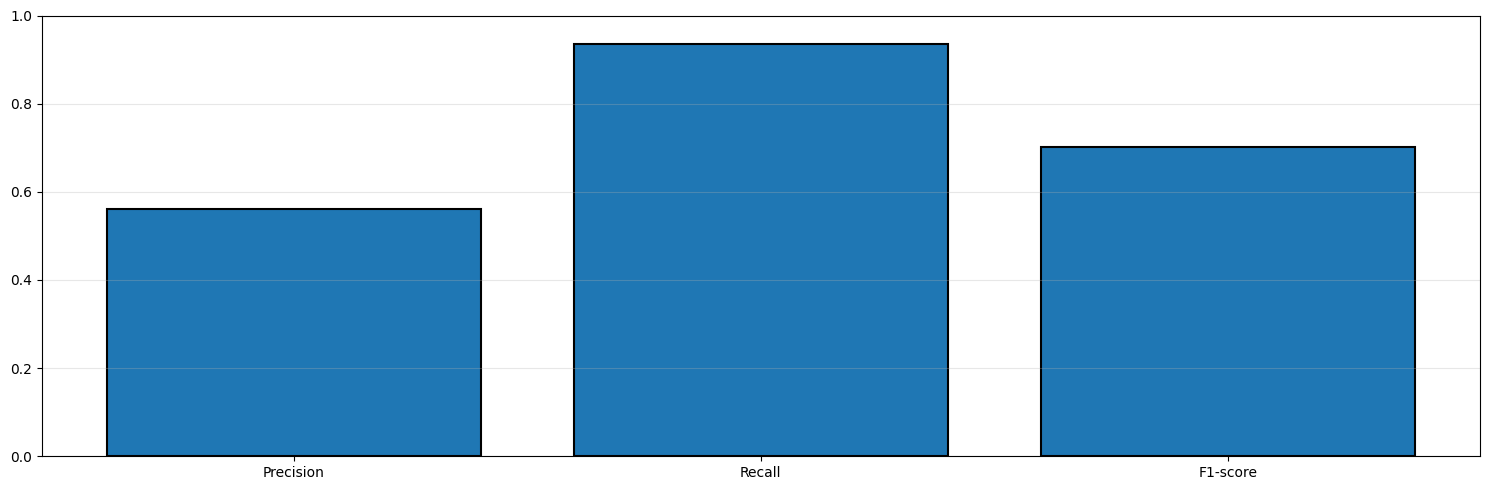

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))

metrics_values =  [metrics['precision'], metrics['recall'], metrics['f1']]
metrics_names = ['Precision', 'Recall', 'F1-score']
bars = axes.bar(metrics_names, metrics_values, edgecolor='black', linewidth=1.5)
axes.set_ylim(0, 1)
axes.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

DEER эффективен для использованных данных - он успешно находит 94% сущностей, но дает относительно много ложных предсказаний.